# Regresión Logística

La naturaleza de este lagoritmo paramétrico asume una relación lineal entre las variables predictoras y el logaritmo de las probabilidades de la variable objetivo. Se implementa como el modelo base. Su propósito en este proyecto es evaluar empíricamente si existe alguna frontera de decisión lineal simple en el dataset. Además, ofrece una alta interpretabilidad a través de los coeficientes de las variables, sirviendo como punto de comparación para algoritmos más complejos.

In [ ]:
pip install imbalanced-learn

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve,
    auc)

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [3]:
df = pd.read_csv("spotify_churn_dataset.csv")

## Preprocesamiento de los datos

In [4]:
print("Eliminando user_id ya que es un identificador sin varianza predictiva.")
df = df.drop(columns=['user_id'])

Eliminando user_id ya que es un identificador sin varianza predictiva.


Durante la evaluación de la matriz de correlación de Pearson, en el análisis exploratorio de los datos (EDA), se detectó una fuerte correlación negativa de -0.88 entre las variables `ads_listened_per_week` y `offline_listening`.

Mantener ambas variables afectaría la estabilidad de los pesos y el cálculo de distancias hiperdimensionales en el SVM. Se elimina la variable binaria y se conserva `ads_listened_per_week` (continua, 0-49), ya que subsume la información de la primera y aporta información crítica sobre la intensidad de la fricción publicitaria, un factor clave para predecir el *churn*.

In [5]:
df = df.drop(columns=['offline_listening'])

### Preparación de los datos para Resampling

Primero, necesitamos separar nuestras características (X) de nuestra variable objetivo (y) y realizar una codificación *one-hot* para las variables categóricas, ya que las técnicas de resampling operan sobre datos numéricos.

In [8]:
# Separar características (X) y variable objetivo (y)
X = df.drop('is_churned', axis=1)
y = df['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
cat_cols = ['gender', 'country', 'subscription_type', 'device_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols), # El escalado se hace dentro del pipeline luego de la transformación polinomial
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Dimensiones después de codificar: {X_train_transformed.shape}")

Dimensiones después de codificar: (6400, 19)


Usamos *stratify=y* en el split para asegurarnos que en el `train_test_split`, tanto el conjunto de entrenamiento como el de prueba mantengan la proporción original del *74/26*.

## Implementación del modelo base



Primero, para establecer un punto de referencia, creamos una función regresion_logistica_poly que usa los hiperparámetros por defecto, validando que el preprocesamiento y escalado de datos funcione correctamente antes de complejizar el modelo.

In [9]:
def regresion_logistica_poly(degree, max_iter, X_train, X_test, y_train, y_test):
    """
    Recibe datos sin escalar. Aplica polinomios, escala la matriz completa,
    aplica SMOTE y entrena el modelo.

    Retorna: grado, número de características, log_loss, accuracy, F1_score, y_pred
    """
    # 1. Crear las características polinomiales
    if degree > 1:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)
    else:
        X_train_poly = X_train.copy()
        X_test_poly = X_test.copy()

    # 2. Asegurar que los términos e interacciones queden normalizados
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_test_scaled = scaler.transform(X_test_poly)

    # 3. Aplicar SMOTE a los datos ya transformados y escalados
    smt = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smt.fit_resample(X_train_scaled, y_train)
    print('Dimensiones de X_train después de SMOTE:', X_train_resampled.shape)
    print('Distribución de clases en Train después de SMOTE:\n', pd.Series(y_train_resampled).value_counts())

    # 4. Entrenar modelo
    model = LogisticRegression(max_iter=max_iter, random_state=42, solver='lbfgs')
    model.fit(X_train_resampled, y_train_resampled)

    # 5. Predicciones y Métricas
    y_pred = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    calculated_loss = log_loss(y_test, y_pred_prob)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    return (degree, X_train_scaled.shape[1], round(calculated_loss, 4), round(acc, 4), round(f1, 4), y_pred)

La función `regresion_logistica_poly` está diseñada para evaluar una regresion logistica con características polinomiales.
- Recibe el grado polinomial, el número máximo de iteraciones y el training/test dataset sin escalar.
- Para grados mayores a 1, genera las características polinomiales usando `include_bias=False` en las características polinomiales porque el objeto `LogisticRegression` de *scikit-learn* ya calcula e introduce el intercepto de forma nativa. Dejarlo en True habría generado una redundancia al duplicar la columna constante de unos dentro de la matriz extendida
- Utiliza `StandardScaler`para normalizar los datos una vez transformados por el polinomio, garantizando que el modelado no sea dominado por aquellas variables con valores grandes.
- Usa SMOTE como técnica de sobremuestreo para balancear la distribución de las clases en el entrenamiento.
- Finalmente, luego de predecir, calcula las métricas `log_loss`,`accuracy_score` y `f1_score`.

### Evaluación del Modelo

In [10]:
iteraciones = 1000
_, _, loss_r, accuracy_r, f1_r, y_pred_model = regresion_logistica_poly(1, iteraciones, X_train_transformed, X_test_transformed, y_train, y_test)
print(f"\nResultado de la regresión logística:\nlog_loss: {loss_r}\naccuracy: {accuracy_r}\nf1: {f1_r}")

Dimensiones de X_train después de SMOTE: (9486, 19)
Distribución de clases en Train después de SMOTE:
 is_churned
0    4743
1    4743
Name: count, dtype: int64

Resultado de la regresión logística:
log_loss: 0.6944
accuracy: 0.5088
f1: 0.4746


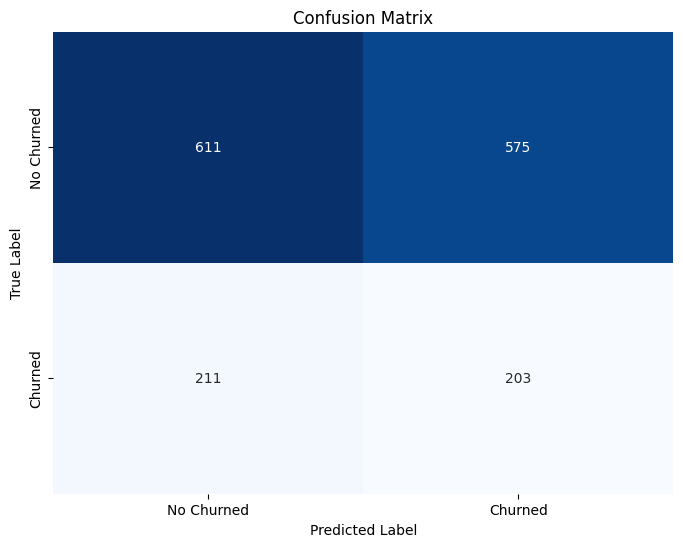


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.52      0.61      1186
           1       0.26      0.49      0.34       414

    accuracy                           0.51      1600
   macro avg       0.50      0.50      0.47      1600
weighted avg       0.62      0.51      0.54      1600



In [11]:
y_pred = y_pred_model
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churned', 'Churned'], yticklabels=['No Churned', 'Churned'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Mostrar el reporte de clasificación
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

La matriz de confusión revela que el modelo está operando casi al azar. Notamos que el modelo clasifica erróneamente a casi la mitad de los usuarios activos (575 Falsos Positivos). Aunque el SMOTE ayudó a que el modelo no ignorara la clase minoritaria, el costo fue un aumento masivo de errores en la clase mayoritaria. Esto sugiere que no hay una frontera de decisión clara entre un usuario que hace churn y uno que no, utilizando las variables en su estado original.

### Mejora del Modelo: Hiperparámetros (C para Regresión Logística)

El parámetro *C* en `LogisticRegression` es el inverso de la fuerza de regularización; valores más pequeños especifican una regularización más fuerte. La regularización ayuda a prevenir el sobreajuste.

Usamos `ImbPipeline` de la librería `imblearn` porque asegura que, dentro de cada iteración del Cross-Validation, el sobremuestreo (SMOTE) solo genere datos sintéticos en los *folds* de entrenamiento, manteniendo los datos de prueba puros. Sin el pipeline, los resultados de exactitud estarían inflados artificialmente.

Además, el pipeline encapsula el escalamiento, la generación de polinomios y la regresión en un solo objeto; sin él, el proceso de optimización requeriría la escritura de múltiples ciclos anidados (un ciclo para los grados del polinomio, otro para los valores de *C*, otro para las penalizaciones, y otro para los *folds* de la Validación Cruzada). Esto no solo hace que el código sea más propenso a errores humanos, sino que dificulta su mantenimiento.

En lugar de seleccionar parámetros al azar, utilizamos `GridSearchCV` con validación cruzada de 5 *folds* (cv=5). Esto permite encontrar la combinación óptima de Regularización (C) y Penalización (L1 vs L2) que minimice el `log_loss`, asegurando que el modelo final sea la versión estadísticamente más robusta posible dentro de las limitaciones del dataset

In [21]:
pipeline = ImbPipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    # utilizamos 'saga' como solver porque es el único que soporta l1 y l2 a la vez
    ('logistic', LogisticRegression(max_iter=3000, random_state=42, solver='saga'))
])

param_grid = {
    'poly__degree': [1, 2],
    'logistic__C': [0.01, 0.1, 1, 10],
    'logistic__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_log_loss',
    n_jobs=-1
)

print("Buscando la mejor combinación de grado, C y penalización...")
grid_search.fit(X_train_transformed, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_transformed)
y_probs = best_model.predict_proba(X_test_transformed)

print("\n--- RESULTADOS DEL MEJOR MODELO ---")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Log Loss: {log_loss(y_test, y_probs):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_probs[:, 1]):.4f}")

print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

Buscando la mejor combinación de grado, C y penalización...

--- RESULTADOS DEL MEJOR MODELO ---
Mejores parámetros: {'logistic__C': 0.01, 'logistic__penalty': 'l1', 'poly__degree': 2}
Accuracy: 0.4800
Log Loss: 0.6919
ROC-AUC: 0.5053

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.74      0.46      0.57      1186
           1       0.26      0.54      0.35       414

    accuracy                           0.48      1600
   macro avg       0.50      0.50      0.46      1600
weighted avg       0.62      0.48      0.51      1600



Matriz de confusión

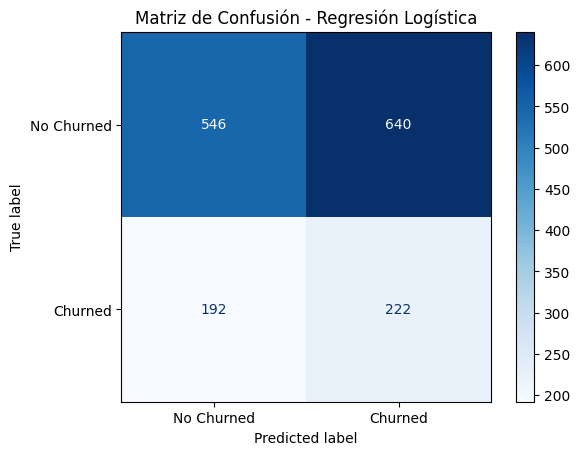

In [15]:
cm_rl = confusion_matrix(y_test, y_pred)
disp_rl = ConfusionMatrixDisplay(confusion_matrix=cm_rl, display_labels=['No Churned', 'Churned'])
disp_rl.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

Curva ROC-AUC

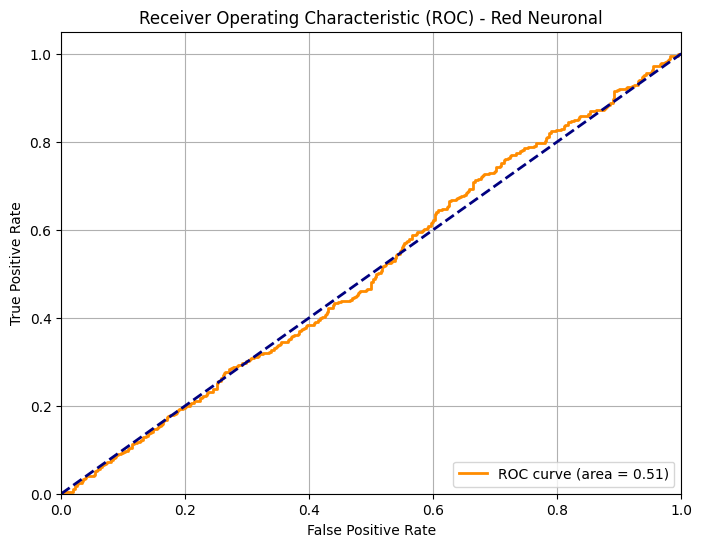

In [22]:
fpr_rl, tpr_rl, thresholds_rl= roc_curve(y_test, y_probs[:, 1])
roc_auc_rl = auc(fpr_rl, tpr_rl)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rl, tpr_rl, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_rl:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Red Neuronal')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

La curva ROC-AUC obtenida (0.5053) se aproxima a la identidad (la diagonal de 45 grados), lo que indica que el clasificador no posee capacidad discriminativa entre las clases. Estadísticamente, esto implica que las funciones de densidad de probabilidad de las variables independientes para ambas categorías (Churn y No-Churn) están prácticamente solapadas. A pesar de la optimización de hiperparámetros mediante GridSearchCV y la creación de términos polinomiales, la ausencia de una 'frontera de decisión' clara sugiere que el dataset carece de variables con poder predictivo real para el fenómeno estudiado.

## Conclusiones

Tras la optimización con hiperparámetros, observamos que las métricas no experimentaron una mejora significativa. La Curva ROC es prácticamente una línea diagonal de 45 grados, lo que visualmente confirma que el modelo tiene una capacidad de discriminación nula (equivalente al azar).

Este resultado, confirma contribuye a evidenciar que el dataset es sintético y
demuestra que incluso aplicando expansión polinomial (grado 2) para capturar relaciones no lineales y regularización Lasso (L1) para descartar ruido, si los datos no contienen una señal real de comportamiento humano, el algoritmo no podrá predecir el churn.
